In [1]:
import os
import numpy as np
import torch
import torch.optim as optim
import random
import pickle

from environment import LatticeTASEP
from DQN import ReplayMemory, DQN
from training import Training
import utils
from utils import Storage, Visualization
from posttraining import Posttraining

import matplotlib.pyplot as plt
from IPython.display import HTML

In [2]:
# Reproducibility
# random.seed(1234)
# np.random.seed(1234)
# torch.manual_seed(1234)

In [ ]:
# ==================================================
# Training
# ==================================================

runsNumber = 25
if torch.cuda.is_available():
    episodes = 1000
else:
    episodes = 50
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Load = False

# Hyperparameters for environment
env_params = {
    'render_mode': None,
    'mode': "random",        
    'Lx': 6,
    'Ly': 2,
    'N': 6,
    'max_steps': 6, # Same as number of particles
    'mu': 0.5, 
    'fixed_sigma': 100                       
}

# Hyperparameters for reinforcement learning algorithm
rl_params = {
    'BATCH_SIZE': 300,
    'GAMMA': 0.99,
    'EPS_START': 0.9,
    'EPS_END': 0.05,
    'EPS_DECAY': 80000, 
    'TAU': 5e-2,
    'LR': 1e-2
}

# ================================================== 
# Initialize environment
# ================================================== 
env = LatticeTASEP(env_params)
playground = Training(env_params, rl_params, device, log = False)

# ================================================== 
# Initialize reinforcement learning algorithm
# ================================================== 
n_actions = env_params['N'] #The number of particles in the system
observation, state, NN_input, info = env.reset()     # Get the number of state observations: The size of the lattice Lx*Ly (int from 0 to Lx*Ly or an array with labelled particles)
n_observations = np.size(NN_input)
hidden_sizes = np.ones(64, dtype=np.int32)*128 #64 hidden layers of 128 nodes
policy_net = DQN(n_observations, n_actions, hidden_sizes).to(device)  # We create an instance of DQN, and move it to the device
target_net = DQN(n_observations, n_actions, hidden_sizes).to(device)    
memory = ReplayMemory(10000)
storage = Storage(env_params, rl_params, runsNumber, episodes)

if Load == False:
    target_net.load_state_dict(policy_net.state_dict()) # Using fixed parameters from the policy network. 
                                                    # state_dict(): Python dictionary object that maps each layer to its parameter tensor (W,B)
    data_storage = {'consecutive_current':[], 'average_loss':[], 'cumulative_reward':[], 'JumpRate_short_Tot':[]} # to use when there is no data loaded

else:
    # recap_file = open(f"trainings/{'training_storage.pkl'}", 'rb')
    # training_storage = pickle.load(recap_file)
    # recap_file = open(f"trainings/{'data_storage.pkl'}", 'rb')
    # data_storage = pickle.load(recap_file)
    utils.load_data_from_file('training_storage.pkl', training_storage)
    policy_net.load_state_dict(training_storage['policy_NN'])
    target_net.load_state_dict(training_storage['target_NN'])
    memory.fill(training_storage['memory'])

optimizer = optim.AdamW(policy_net.parameters(), lr=rl_params['LR'], amsgrad=True)

CurrentAlongTot, CurrentAlongPerRun, lossTot, rewardsTot, JumpRate_movie, JumpRate_short_movie, JumpRate_short_Tot = playground.simulate(runsNumber, episodes, memory, policy_net, target_net, optimizer)

if Load == True:
    runsNumber = training_storage['hyperparameters']['runsNumber'] + runsNumber
    totalMCS = training_storage['hyperparameters']['episodes'] + episodes


training_storage, data_storage = storage.update_dictionaries(runsNumber, episodes, policy_net, target_net, memory, CurrentAlongTot, CurrentAlongPerRun, lossTot, rewardsTot, JumpRate_short_Tot, Load, data_storage)
    
utils.save_data_to_file('training_storage.pkl', training_storage)
utils.save_data_to_file('data_storage.pkl', data_storage)

#print('Current Along Total', CurrentAlongTot.size)

 56%|█████▌    | 14/25 [05:07<04:24, 24.07s/it]

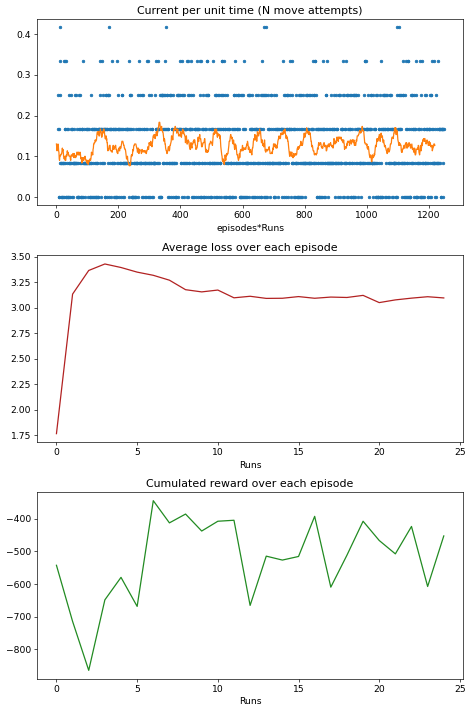

In [3]:
# # Last data from the file
# recap_file = open(f"trainings/{'data_storage.pkl'}", 'rb')
# Last_data_storage = pickle.load(recap_file)
# plot = Visualization(Last_data_storage)
# env_params = {
#     'render_mode': None,
#     'mode': "chess",        
#     'Lx': 4,
#     'Ly': 2,
#     'N': 4,

#     'max_steps': 4,
#     'mu': 0.5, 
#     'fixed_sigma': 100                       
# }

# # Hyperparameters for reinforcement learning algorithm
# rl_params = {
#     'LR': 1e-2
# }

plot = Visualization(data_storage)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 60
plt.rcParams["font.size"] = 11

# Fixed sigma plots
#plot.current_plot(env_params['fixed_sigma'])

# Different sigmas plots
#currents_sigmas_plot()
#average_run_current_over_sigmas()

#loss_plot()

plot.create_combined_plot(env_params['Lx'], env_params['Ly'], env_params['fixed_sigma'], rl_params['LR'], lines = 10, save = False)


In [4]:
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

def create_animation(Frames_movie):
    fig, ax = plt.subplots()
    div = make_axes_locatable(ax)
    cax = div.append_axes('right', '5%', '5%')
    
    cv0 = Frames_movie[0]
    im = ax.imshow(cv0, cmap="gnuplot")
    cb = fig.colorbar(im, cax=cax)
    
    tx2 = ax.set_title('Frame 0 after one MCS of the last run', y=1)
    
    ax.axis('off')
    plt.close()  # To not have the plot of frame 0

    def animate(frame):
        arr = Frames_movie[frame]
        vmax = 1
        vmin = np.min(arr)
        im.set_data(arr)
        im.set_clim(vmin, vmax)
        cb.ax.set_ylabel('Jumping Rate')
        tx2.set_text('Frame {0}'.format(frame))

    ani = FuncAnimation(fig, animate, frames=len(Frames_movie), repeat=False)
    return ani

# Movie
# # Last data from the file
# recap_file = open(f"trainings/{'data_storage.pkl'}", 'rb')
# Last_data_storage = pickle.load(recap_file)
#ani = create_animation(Last_data_storage['JumpRate_short_Tot'][45,:])

# ani = create_animation(data_storage['jump_rate_short'][-602:])
ani = create_animation(JumpRate_short_Tot[runsNumber - 1,:])

HTML(ani.to_jshtml())
#ani.save('Pictures/2animation12x6_Runs50_MCS100_LearningRate0.01.mp4')

In [11]:
# ==================================================
# Post-Training
# ==================================================
# It applies the last trained NN and calculates the current using MonteCarlo simulations

runsNumber = 100
if torch.cuda.is_available():
    totalMCS = 1000
else:
    totalMCS = 100
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters for environment
env_params = {
    'render_mode': None,
    'mode': "chess",        
    'Lx': 6,
    'Ly': 3,
    'N': 9,
    'max_steps': 9,
    'mu': 0.5, 
    'fixed_sigma': 100                       
}


# ================================================== 
# Initialize environment
# ================================================== 
env = LatticeTASEP(env_params)
playground = Posttraining(env_params, device, log = False)

recap_file = open(f"trainings/{'training_storage.pkl'}", 'rb')
Last_training_storage = pickle.load(recap_file)

n_actions = env.action_space.n     # Get number of actions from gym action space: The number of particles in the system
observation, state, NN_input, info = env.reset()     # Get the number of state observations: The size of the lattice Lx*Ly (int from 0 to Lx*Ly or an array with labelled particles)
n_observations = np.size(NN_input)

policy_net = DQN(n_observations, n_actions).to(device)  # We create an instance of DQN, and move it to the device
policy_net.load_state_dict(Last_training_storage['policy_NN'])


## Calculate the current with the dynamics of the trained NN 
CurrentAlongTot, CurrentTransvTot, RunMovie_short, RunMovie = playground.simulate(runsNumber, totalMCS, policy_net, 'bestWoRepeating')

MCS_storage = {}
MCS_storage['CurrentAlongTot'] = CurrentAlongTot
MCS_storage['CurrentTransvTot'] = CurrentTransvTot        
MCS_storage['RunMovie_short'] = RunMovie_short
MCS_storage['RunMovie'] = RunMovie
utils.save_data_to_file('MCS_storage.pkl', MCS_storage)


100%|██████████| 100/100 [00:29<00:00,  3.33it/s]

Complete


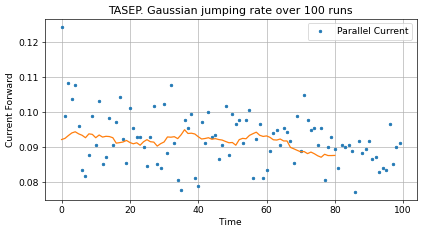

In [12]:
def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# recap_file = open(f"trainings/{'MCS_storage.pkl'}", 'rb')
# Last_MCS_storage = pickle.load(recap_file)
# plot = Visualization(Last_MCS_storage)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["figure.dpi"] = 60
plt.rcParams["font.size"] = 11

plt.cla()
plt.title(f"TASEP. Gaussian jumping rate over {runsNumber} runs")
plt.xlabel('Time')
plt.ylabel(f'Current Forward')
plt.grid(True)

x_axis=np.array(range(totalMCS))

# Choose the window size for the moving average
window_size = 15
# Calculate the moving average
moving_avg = moving_average(CurrentAlongTot[5:], window_size)
# Adjust time to match the moving average length
adjusted_time = x_axis[:len(moving_avg)]


plt.plot(x_axis, CurrentAlongTot, '.', label='Parallel Current')
#plt.plot(x_axis[5:], CurrentTransvTot[5:], '.', label='Perpendicular Current')
#plt.plot(x_axis, f, label='Theoretical Parallel Current', color = 'red')
plt.plot(adjusted_time, moving_avg)
plt.legend()

In [13]:
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

def create_animation(Frames_movie):
    fig, ax = plt.subplots()
    div = make_axes_locatable(ax)
    cax = div.append_axes('right', '5%', '5%')
    
    cv0 = Frames_movie[0]
    im = ax.imshow(cv0, cmap="gnuplot")
    cb = fig.colorbar(im, cax=cax)
    
    tx2 = ax.set_title('Frame 0 after one MCS of the last run', y=1)
    
    ax.axis('off')
    plt.close()  # To not have the plot of frame 0

    def animate(frame):
        arr = Frames_movie[frame]
        vmax = 1
        vmin = np.min(arr)
        im.set_data(arr)
        im.set_clim(vmin, vmax)
        cb.ax.set_ylabel('Jumping Rate')
        tx2.set_text('Frame {0}'.format(frame))

    ani = FuncAnimation(fig, animate, frames=len(Frames_movie), repeat=False)
    return ani

# Movie
# Last data from the file
recap_file = open(f"trainings/{'MCS_storage.pkl'}", 'rb')
Last_MCS_storage = pickle.load(recap_file)
ani = create_animation(Last_MCS_storage['RunMovie_short'][0,:])

HTML(ani.to_jshtml())
#ani.save('Pictures/2animation12x6_Runs50_MCS100_LearningRate0.01.mp4')

100%|██████████| 100/100 [00:23<00:00,  4.34it/s]

Complete


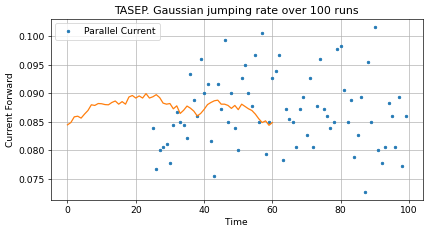

In [14]:
# ==================================================
# Random simulation
# ==================================================
CurrentAlongTot_Rand, CurrentTransvTot_Rand, RunMovie_short_Rand, RunMovie_Rand = playground.simulate(runsNumber, totalMCS, policy_net, 'random')

plt.cla()
plt.title(f"TASEP. Gaussian jumping rate over {runsNumber} runs")
plt.xlabel('Time')
plt.ylabel(f'Current Forward')
plt.grid(True)

x_axis=np.array(range(totalMCS))

# Choose the window size for the moving average
window_size = 15
# Calculate the moving average
moving_avg = moving_average(CurrentAlongTot_Rand[25:], window_size)
# Adjust time to match the moving average length
adjusted_time = x_axis[:len(moving_avg)]


plt.plot(x_axis[25:], CurrentAlongTot_Rand[25:], '.', label='Parallel Current')
#plt.plot(x_axis[5:], CurrentTransvTot[5:], '.', label='Perpendicular Current')
#plt.plot(x_axis, f, label='Theoretical Parallel Current', color = 'red')
plt.plot(adjusted_time, moving_avg)
plt.legend()

In [15]:
from matplotlib.animation import FuncAnimation
from mpl_toolkits.axes_grid1 import make_axes_locatable

def create_animation(Frames_movie):
    fig, ax = plt.subplots()
    div = make_axes_locatable(ax)
    cax = div.append_axes('right', '5%', '5%')
    
    cv0 = Frames_movie[0]
    im = ax.imshow(cv0, cmap="gnuplot")
    cb = fig.colorbar(im, cax=cax)
    
    tx2 = ax.set_title('Frame 0 after one MCS of the last run', y=1)
    
    ax.axis('off')
    plt.close()  # To not have the plot of frame 0

    def animate(frame):
        arr = Frames_movie[frame]
        vmax = 1
        vmin = np.min(arr)
        im.set_data(arr)
        im.set_clim(vmin, vmax)
        cb.ax.set_ylabel('Jumping Rate')
        tx2.set_text('Frame {0}'.format(frame))

    ani = FuncAnimation(fig, animate, frames=len(Frames_movie), repeat=False)
    return ani

# Movie
# Last data from the file
recap_file = open(f"trainings/{'MCS_storage.pkl'}", 'rb')
Last_MCS_storage = pickle.load(recap_file)
ani = create_animation(RunMovie_short_Rand[4,:])

HTML(ani.to_jshtml())
#ani.save('Pictures/2animation12x6_Runs50_MCS100_LearningRate0.01.mp4')